Let's test the idea that the *area* under the curves is responsible for the total variance of these operators (whatever that means!)

Something that I do think is true is that we can treat the structure factor as a response function to momentum excitations.

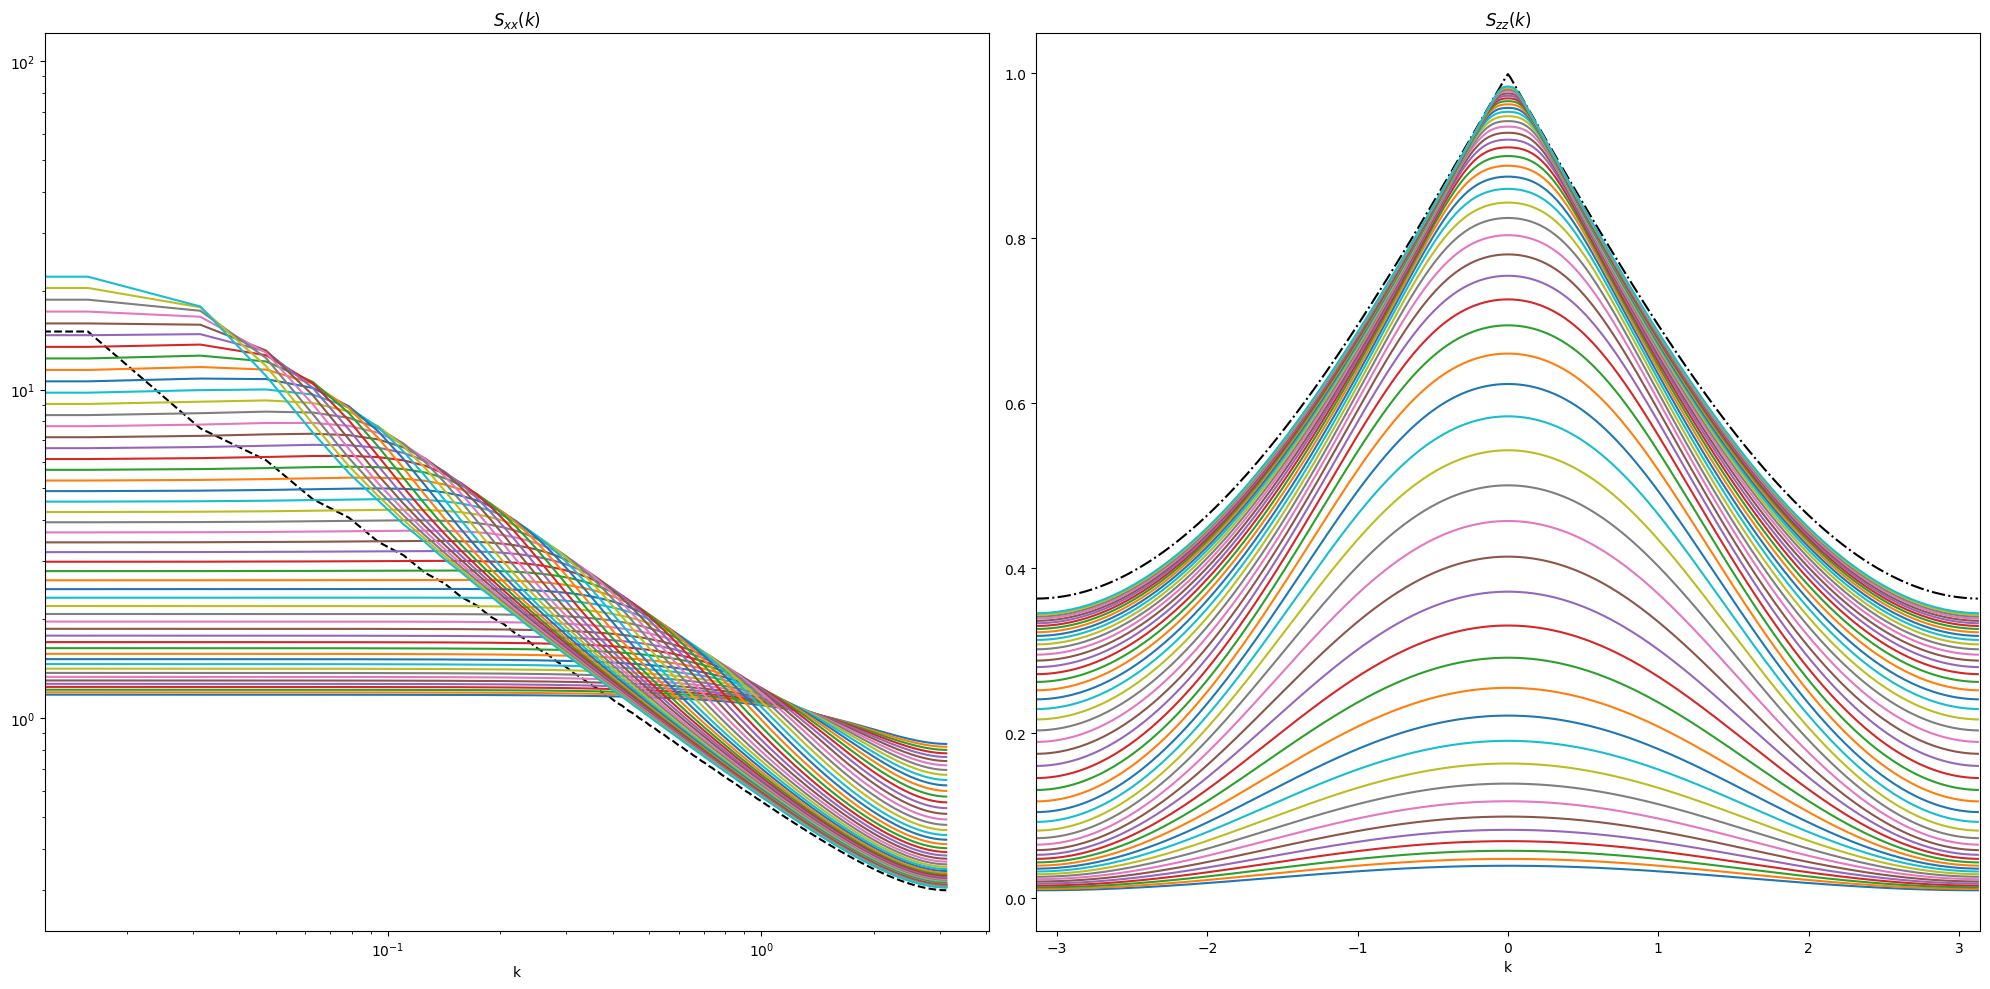

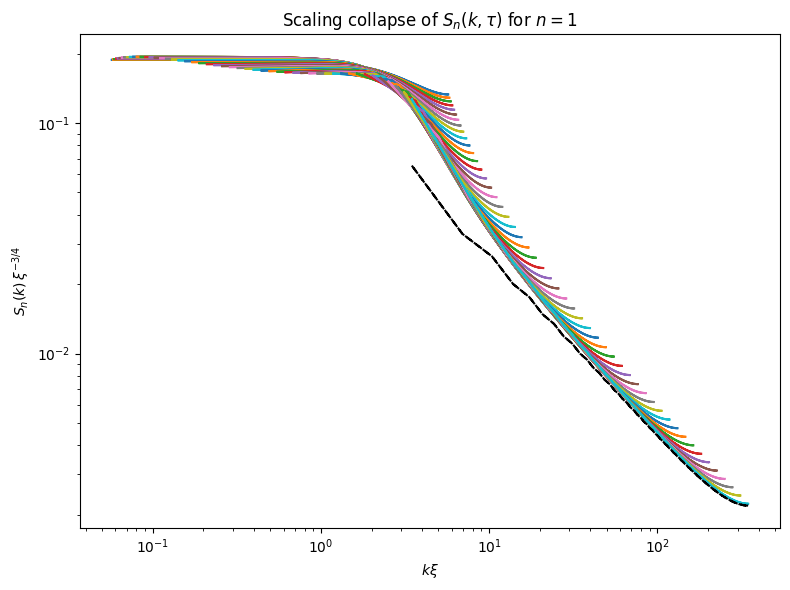

In [50]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x

from equilibrium_z_projectors import sigma_general as sigma_z

import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift

foldername = "Figures/"




/tmp/ipykernel_7026/2922134618.py:14: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
/tmp/ipykernel_7026/2922134618.py:15: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
/tmp/ipykernel_7026/2922134618.py:15: RuntimeWarning: invalid value encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")


Text(0.5, 0, 'r')

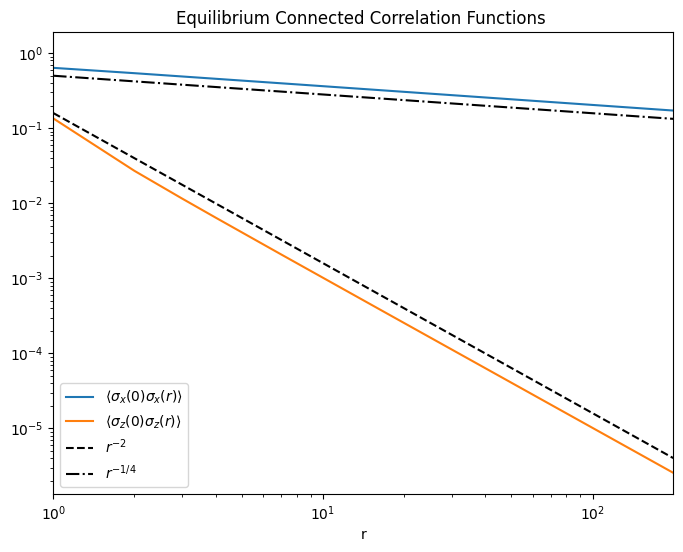

In [51]:
r = np.arange(-200,200)

xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"

C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])


plt.figure(figsize=(8,6))

plot(r,C_xx,label= xx_lab)
plot(r,C_zz,label= zz_lab)
plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
legend()
xlim(1,max(r))
loglog()
title("Equilibrium Connected Correlation Functions ")
xlabel("r")

XX= 1.0776644660950359
ZZ= 1.5915593781211096e-05


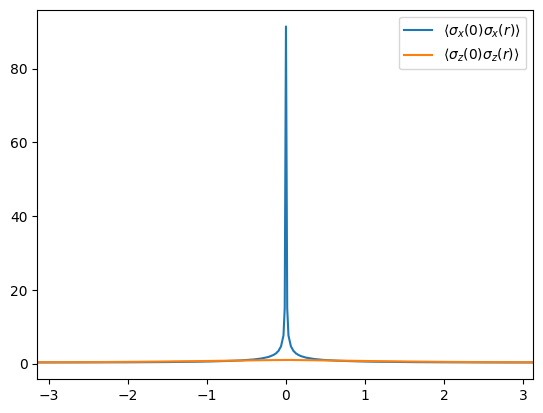

In [35]:
def K(r):
    return fftshift(fftfreq(len(r),1))*2*pi

def FT(x):
    return fftshift(fft(x))


k = K(r)
F_xx = FT(C_xx)
F_zz = FT(C_zz)

plot(k,abs(F_xx),label = xx_lab)
plot(k,abs(F_zz),label=  zz_lab)
xlim(min(k),max(k))
legend()


dk = k[1]-k[0]
print(f"XX= {np.real(sum(F_xx)*dk)}")
print(f"ZZ= {np.real(sum(F_zz)*dk)}")


So the idea here is that $S_{zz}(k)$ is very weak and this operator doesnt fluctuate or something. Or maybe that it's not so responsive to quenches.



# Let's Quench

In [37]:
taus = np.logspace(-2,2.5,50)

import kibble_zurek as kibble_x
import time_evolved_z_correlators as kibble_z

In [33]:
L = 500
states = [kibble_x.state(L,tau,0) for tau in taus]

rho = array([sigma_x([0,1])- kibble_x.sigma_general([0,1],s) for s in states])
r = np.arange(-200,200)
quenched_xx = [array([kibble_x.sigma_general([0,ri],s) for ri in tqdm(r)]) for s in states]


KeyboardInterrupt: 

In [38]:
from joblib import Parallel, delayed
import numpy as np
from tqdm import tqdm

L = 500
r = np.arange(-200, 200)

# --- parallel state generation ---
states = Parallel(n_jobs=-1)(
    delayed(kibble_x.state)(L, tau, 0) for tau in tqdm(taus)
)
print("Done")
# --- parallel correlation computation ---
def compute_corr(s):
    return np.array([kibble_x.sigma_general([0, ri], s) for ri in r])

quenched_xx = Parallel(n_jobs=-1)(
    delayed(compute_corr)(s) for s in tqdm(states)
)



100%|██████████| 50/50 [00:01<00:00, 34.81it/s]


Done


  0%|          | 0/50 [00:00<?, ?it/s]/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scrip

In [39]:
quenched_zz = [array([kibble_z.sigma_general([0,ri],s)-kibble_z.sigma_general([0],s)**2 for ri in (r)]) for s in states]

/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


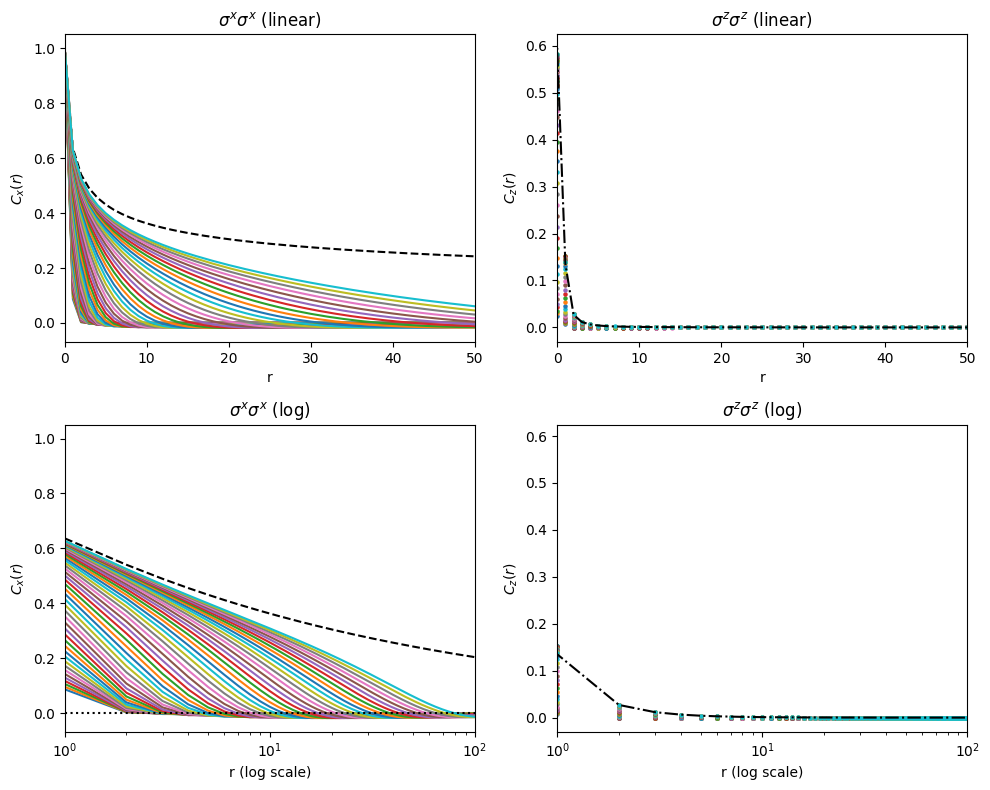

In [40]:
ri = np.arange(-200, 200)
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharey=False)

# --- linear scale σ^xσ^
# 
# x ---
axs[0, 0].plot(r, C_xx, "--k", label=xx_lab)
for i, tau in enumerate(taus):
    xx = quenched_xx[i]
    axs[0, 0].plot(r, xx, label=rf"$\tau$ = {tau}")
axs[0, 0].set_xlabel("r")
axs[0, 0].set_ylabel(r"$C_x(r)$")
axs[0, 0].set_xlim(0, 50)
#axs[0, 0].legend()
axs[0, 0].set_title(r"$\sigma^x\sigma^x$ (linear)")

# --- linear scale σ^zσ^z ---
axs[0, 1].plot(r, C_zz, "-.k", label=zz_lab)
for i, tau in enumerate(taus):
    zz = quenched_zz[i]
    axs[0, 1].scatter(r, zz, s=5, label=rf"$\tau$ = {tau}")
axs[0, 1].set_xlabel("r")
axs[0, 1].set_ylabel(r"$C_z(r)$")
axs[0, 1].set_xlim(0, 50)
#axs[0, 1].legend()
axs[0, 1].set_title(r"$\sigma^z\sigma^z$ (linear)")

# --- log scale σ^xσ^x ---
axs[1, 0].plot(r, C_xx, "--k", label=xx_lab)
for i, tau in enumerate(taus):
    xx = quenched_xx[i]
    axs[1, 0].plot(r, xx, label=rf"$\tau$ = {tau}")
axs[1, 0].set_xscale("log")
axs[1, 0].set_xlim(1, 100)
axs[1, 0].set_xlabel("r (log scale)")
axs[1, 0].set_ylabel(r"$C_x(r)$")
axs[1, 0].hlines(0,1,100,"k",ls=":")
#axs[1, 0].legend()
axs[1, 0].set_title(r"$\sigma^x\sigma^x$ (log)")

# --- log scale σ^zσ^z ---
axs[1, 1].plot(r, C_zz, "-.k", label=zz_lab)
for i, tau in enumerate(taus):
    zz = quenched_zz[i]
    axs[1, 1].scatter(r, zz, s=5, label=rf"$\tau$ = {tau}")
axs[1, 1].set_xscale("log")
axs[1, 1].set_xlim(1, 100)
axs[1, 1].set_xlabel("r (log scale)")
axs[1, 1].set_ylabel(r"$C_z(r)$")
#axs[1, 1].legend()
axs[1, 1].set_title(r"$\sigma^z\sigma^z$ (log)")

plt.tight_layout()
plt.show()


We see quite plainly that the $\sigma_x \sigma_x$ correlation is significantly more impacted by quenches than the short range correlators associated with the z direction.

In [221]:
rhos = array([(sigma_x([0,1])-kibble_x.sigma_general([0,1],s)) for s in states])

xis = 1/rhos

/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


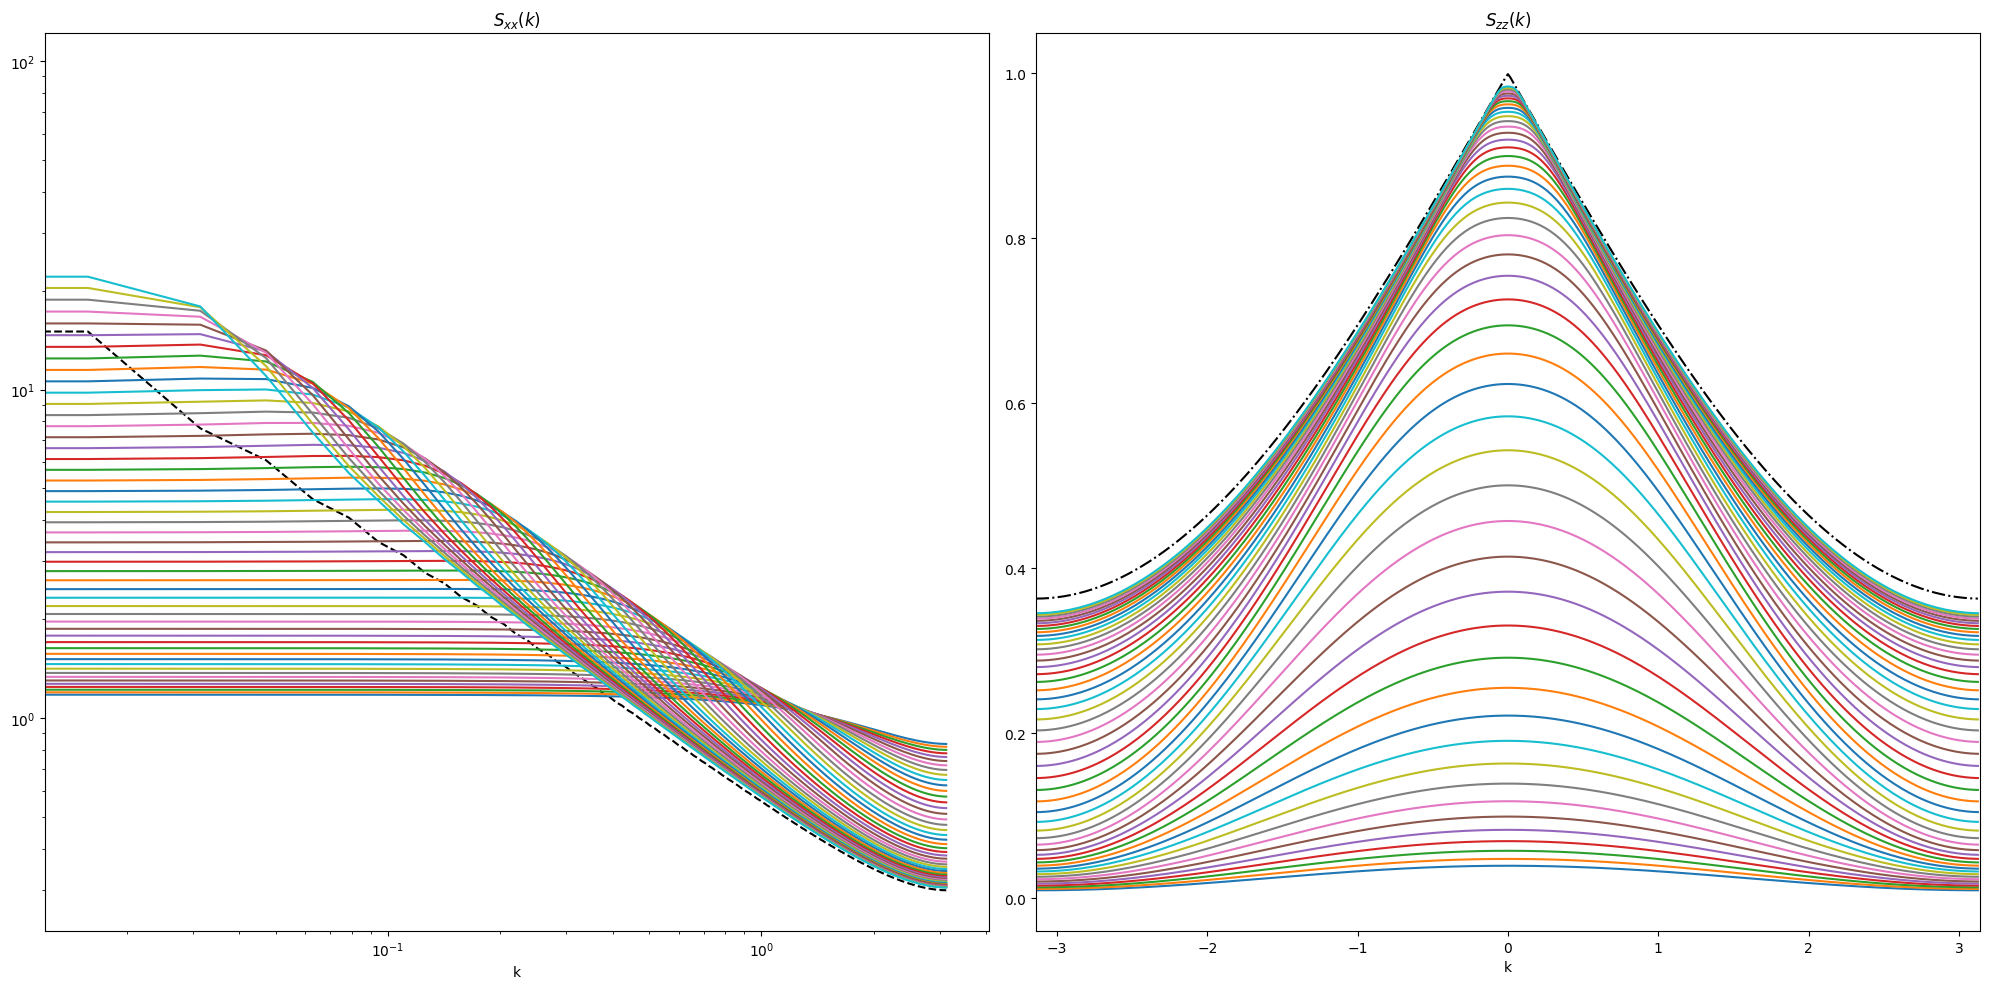

In [349]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10), sharey=False)
k = K(r)
k = array(k)
#ki = K(r)
dk = k[1]-k[0]
# --- σ^xσ^x structure factor ---
S0 = []
axs[0].plot(k, np.abs(FT(C_xx)), '--k', label="EqX")
for i, tau in enumerate(taus):
    F_xx = FT(quenched_xx[i])
    S0.append((abs(F_xx)[k==0]))
   # area_x.append((sum((F_xx)*dk)))
    color = axs[0].plot(k, abs(F_xx), label=rf"$\tau$={tau}")[0].get_color()
S0= array(S0)
#xs[0].set_xlim(dk,2)
#axs[0].set_ylim(0, 25)
#axs[0].legend()
axs[0].set_title(r"$S_{xx}(k)$")
axs[0].set_xlabel("k")
axs[0].loglog()

# --- σ^zσ^z structure factor ---
axs[1].plot(k, np.abs(FT(C_zz)), '-.k', label="EqZ")
area_z = []
for i, tau in enumerate(taus):
    F_zz = FT(quenched_zz[i])
    #area_z.append((sum((F_zz))*dk))
    axs[1].plot(k, abs(F_zz) ,label=rf"$\tau$={tau}")
axs[1].set_xlim(-3.14, 3.14)
#axs[1].set_ylim(0, 0.01)

#axs[1].legend()
axs[1].set_title(r"$S_{zz}(k)$")
axs[1].set_xlabel("k")
#axs[1].loglog()
plt.tight_layout()

k_plot = k.copy()
k_plot = k_plot[k_plot != 0]  # remove k = 0 to avoid divergence


plt.show()

#foldername = "Figures/"
#filename= "S_xx_vs_Szz_zoom.png"

#plt.savefig(foldername+filename,dpi=800)


/tmp/ipykernel_7026/307250521.py:11: RuntimeWarning: divide by zero encountered in reciprocal
  ax.plot(scaled_k,scaled_k**(-1))


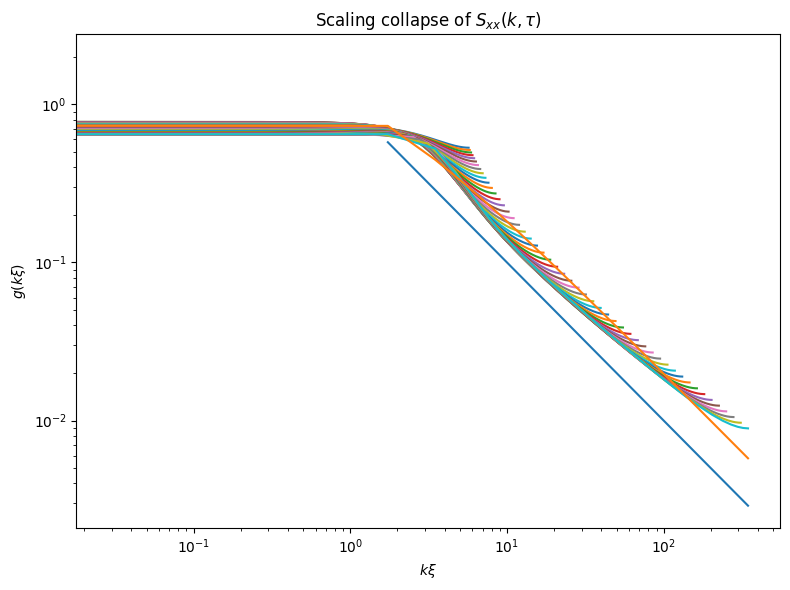

In [323]:
eta_x = 1/4

fig, ax = plt.subplots(figsize=(8,6))
for i in range(0, len(taus), 1):  # skip every 10
    tau = taus[i]
    F_xx = np.abs(FT(quenched_xx[i]))
    scaled_k =  k*xis[i]
    g = F_xx * xis[i]**(-3/4)
    ax.plot(scaled_k, g, label=rf"$\tau={tau}$")
scaled_k =  k*xis[-1]
ax.plot(scaled_k,scaled_k**(-1))
ax.plot(scaled_k,(2)/(1+scaled_k**(1)))
#ax.set_xlim(-100,100)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$k \xi$")
ax.set_ylabel(r"$g(k\xi)$")
ax.set_title(r"Scaling collapse of $S_{xx}(k,\tau)$")
#ax.legend()
plt.tight_layout()
filename = "ScalingCollapseSxx.png"
#plt.savefig(foldername+filename,dpi=8)
plt.show()



/tmp/ipykernel_7026/2657492785.py:11: RuntimeWarning: invalid value encountered in power
  g = F_xx * (k**(3/4))          # correct definition g = S * k^{3/4}
/tmp/ipykernel_7026/2657492785.py:12: RuntimeWarning: divide by zero encountered in divide
  S_over_g = F_xx / g            # = k^{-3/4} if scaling holds


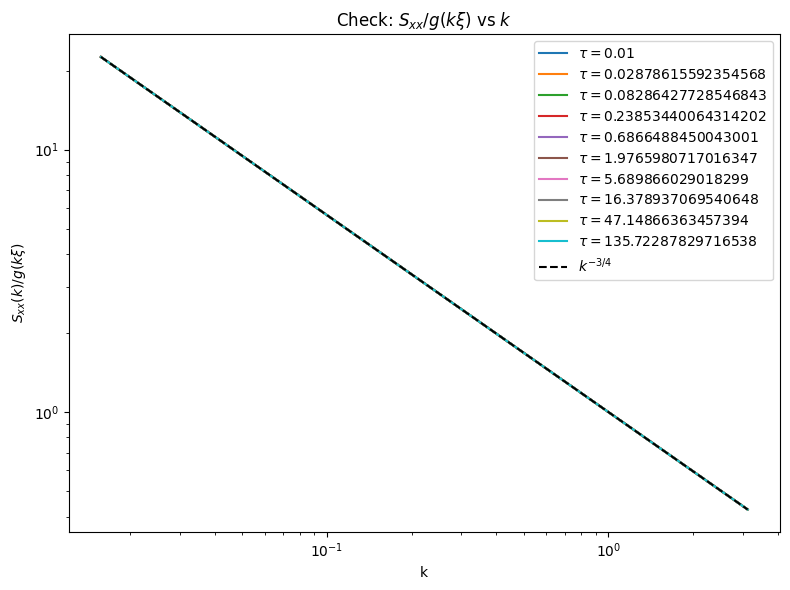

In [343]:
eta_x = 1/4

fig, ax = plt.subplots(figsize=(8,6))

for i in range(0, len(taus), 5):
    tau = taus[i]
    xi = xis[i]
    F_xx = np.abs(FT(quenched_xx[i]))

    scaled_k = k * xi
    g = F_xx * (k**(3/4))          # correct definition g = S * k^{3/4}
    S_over_g = F_xx / g            # = k^{-3/4} if scaling holds

    ax.plot(k, S_over_g, label=rf"$\tau={tau}$")

# reference power law
mask = k > 0
ax.plot(k[mask], k[mask]**(-3/4), '--k', label=r"$k^{-3/4}$")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("k")
ax.set_ylabel(r"$S_{xx}(k)/g(k\xi)$")
ax.set_title(r"Check: $S_{xx}/g(k\xi)$ vs $k$")
ax.legend()
plt.tight_layout()
plt.show()


[]

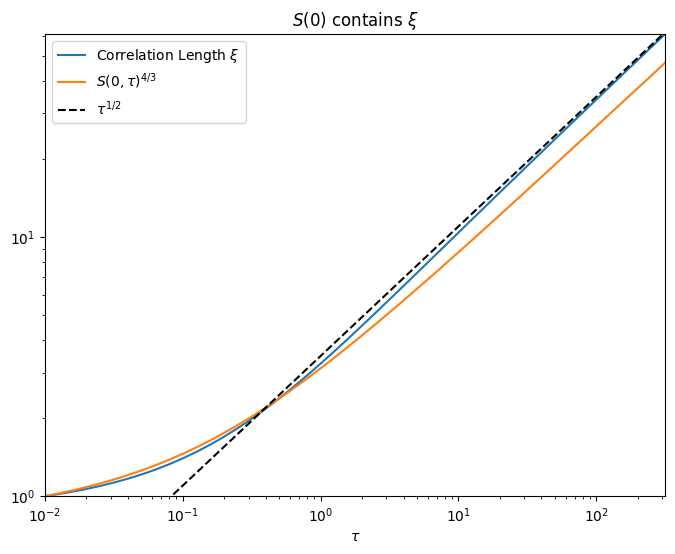

In [209]:
plt.figure(figsize=(8,6))
plot(taus,1/rhos / (1/rhos[0]),label=r"Correlation Length $\xi$")
plot(taus,1*S0**(4/3)/S0[0]**(4/3),label=r"$ S(0,\tau)^{4/3}$")
plot(taus,taus**(1/2)/taus[10]**(1/2),"--k",label=r"$\tau^{1/2}$")

ylim(1,max(1/rhos/(1/rhos[0])))
xlim(taus[0],taus[-1])
xlabel(r"$\tau$")
legend()
title(r"$S(0)$ contains $\xi$")
#plot(taus,taus**(3/8.)/taus[0]**(3/8))
loglog()

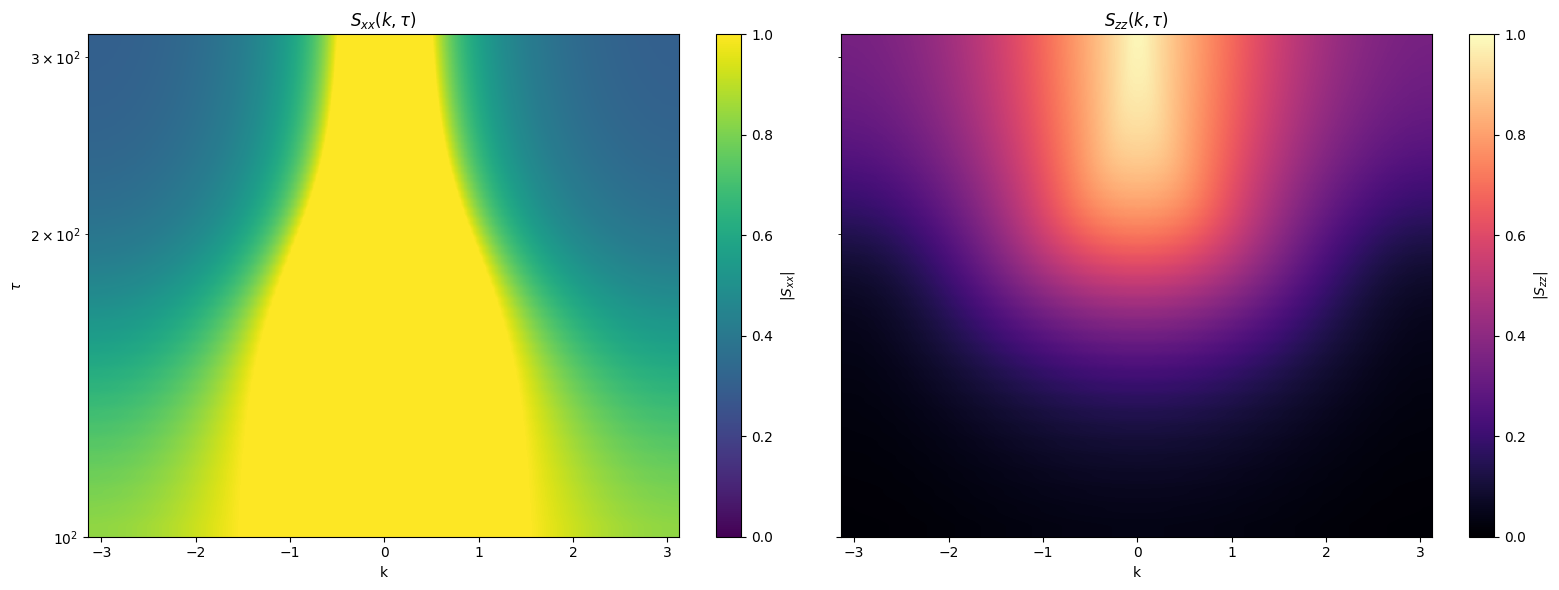

In [109]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

k = K(r)
minttau= 100
# build 2D arrays (taus × k)
Sxx = np.array([np.abs(FT(q)) for q in quenched_xx])
Szz = np.array([np.abs(FT(q)) for q in quenched_zz])

im0 = axs[0].imshow(Sxx, aspect='auto', origin='lower',
                    extent=[k.min(), k.max(), minttau, taus.max()],
                    cmap='viridis',vmin=0,vmax=1)
axs[0].set_title(r"$S_{xx}(k,\tau)$")
axs[0].set_xlabel("k")
axs[0].set_ylabel(r"$\tau$")
axs[0].set_yscale('log')
fig.colorbar(im0, ax=axs[0], label=r"$|S_{xx}|$")

im1 = axs[1].imshow(Szz, aspect='auto', origin='lower',
                    extent=[k.min(), k.max(), minttau, taus.max()],
                    cmap='magma',vmin=0,vmax=1)
axs[1].set_title(r"$S_{zz}(k,\tau)$")
axs[1].set_xlabel("k")
axs[1].set_yscale('log')
fig.colorbar(im1, ax=axs[1], label=r"$|S_{zz}|$")

plt.tight_layout()
plt.show()




In [79]:
print(np.max(np.abs(C_xx)))
print(np.sum(C_xx))


1.0
54.31648039360935


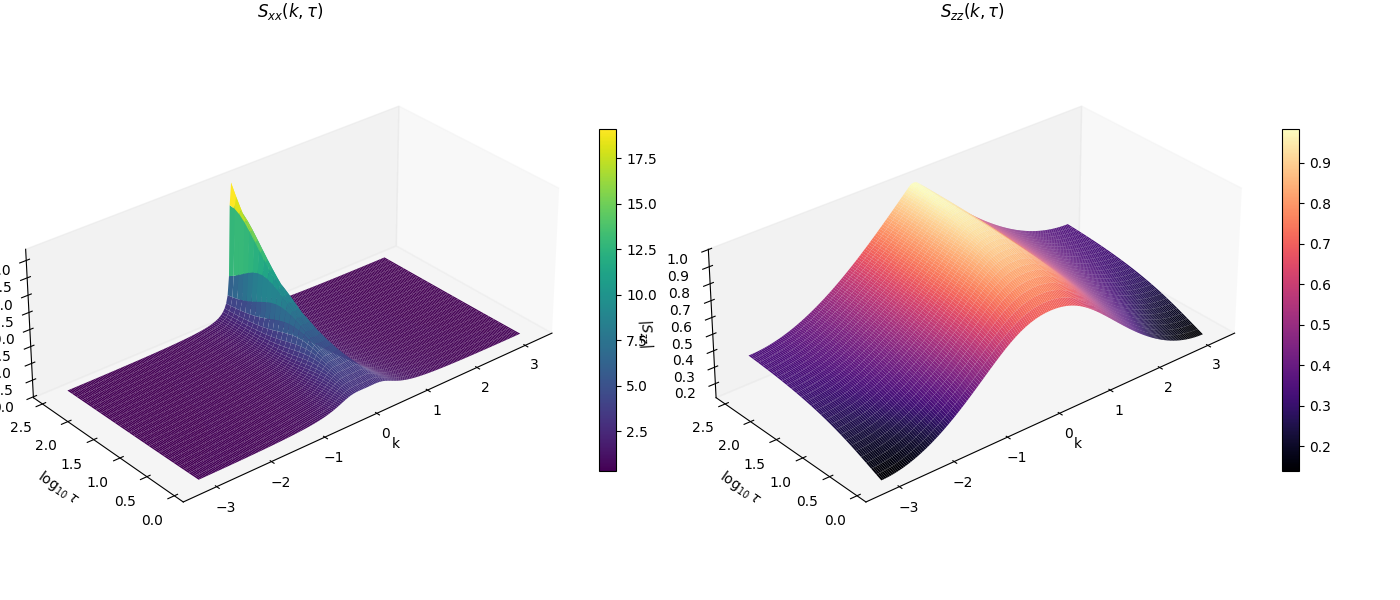

In [115]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

k = K(r)
minttau = 1

Sxx = np.array([np.abs(FT(q)) for q in quenched_xx])
Szz = np.array([np.abs(FT(q)) for q in quenched_zz])

mask = taus >= minttau
taus_plot = taus[mask]
Sxx = Sxx[mask]
Szz = Szz[mask]

# downsample for smoother surface
step_k = max(1, len(k)//200)
step_t = max(1, len(taus_plot)//200)
k_plot = k[::step_k]
t_plot = taus_plot[::step_t]
Sxx_plot = Sxx[::step_t, ::step_k]
Szz_plot = Szz[::step_t, ::step_k]

Kmesh, Tmesh = np.meshgrid(k_plot, t_plot)

fig = plt.figure(figsize=(14, 6))

# --- Sxx ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Kmesh, np.log10(Tmesh), Sxx_plot,
                         cmap='viridis', linewidth=0, antialiased=True,
                         rstride=1, cstride=1, shade=True)
ax1.set_title(r"$S_{xx}(k,\tau)$")
ax1.set_xlabel("k")
ax1.set_ylabel(r"$\log_{10}\tau$")
ax1.set_zlabel(r"$|S_{xx}|$")
fig.colorbar(surf1, ax=ax1, shrink=0.6)

# --- Szz ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Kmesh, np.log10(Tmesh), Szz_plot,
                         cmap='magma', linewidth=0, antialiased=True,
                         rstride=1, cstride=1, shade=True)
ax2.set_title(r"$S_{zz}(k,\tau)$")
ax2.set_xlabel("k")
ax2.set_ylabel(r"$\log_{10}\tau$")
ax2.set_zlabel(r"$|S_{zz}|$")
fig.colorbar(surf2, ax=ax2, shrink=0.6)

# nicer view
for ax in [ax1, ax2]:
    ax.view_init(elev=30, azim=230)
    ax.grid(False)
    ax.set_box_aspect((2, 1, 0.7))

plt.tight_layout()
plt.show()


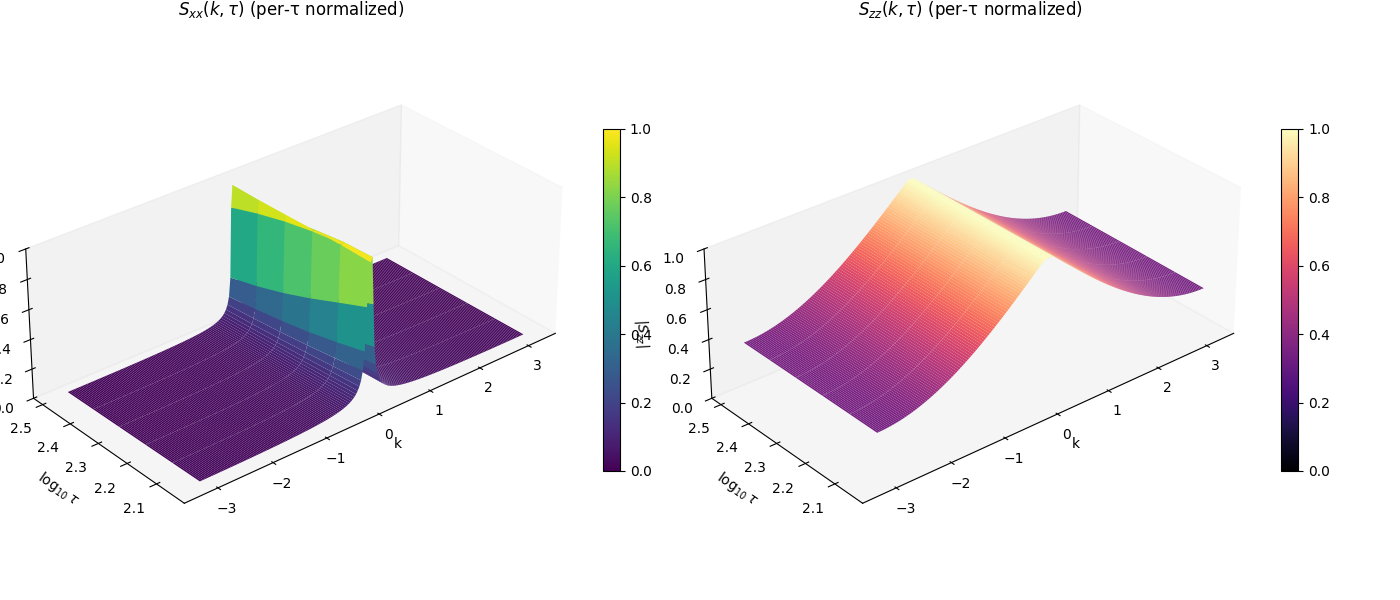

ValueError: 5 is not a valid MouseButton

In [117]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

k = K(r)
minttau = 100

Sxx = np.array([np.abs(FT(q)) for q in quenched_xx])
Szz = np.array([np.abs(FT(q)) for q in quenched_zz])

mask = taus >= minttau
taus_plot = taus[mask]
Sxx = Sxx[mask]
Szz = Szz[mask]

# --- normalize each τ row to its own max = 1 ---
Sxx = Sxx / Sxx.max(axis=1, keepdims=True)
Szz = Szz / Szz.max(axis=1, keepdims=True)

# downsample for smoother plotting
step_k = max(1, len(k)//200)
step_t = max(1, len(taus_plot)//200)
k_plot = k[::step_k]
t_plot = taus_plot[::step_t]
Sxx_plot = Sxx[::step_t, ::step_k]
Szz_plot = Szz[::step_t, ::step_k]

Kmesh, Tmesh = np.meshgrid(k_plot, t_plot)

fig = plt.figure(figsize=(14, 6))

# --- Sxx surface ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Kmesh, np.log10(Tmesh), Sxx_plot,
                         cmap='viridis', linewidth=0, antialiased=True,
                         rstride=1, cstride=1, shade=True, vmin=0, vmax=1)
ax1.set_title(r"$S_{xx}(k,\tau)$ (per-τ normalized)")
ax1.set_xlabel("k")
ax1.set_ylabel(r"$\log_{10}\tau$")
ax1.set_zlabel(r"$|S_{xx}|$")
ax1.set_zlim(0, 1)
fig.colorbar(surf1, ax=ax1, shrink=0.6)

# --- Szz surface ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Kmesh, np.log10(Tmesh), Szz_plot,
                         cmap='magma', linewidth=0, antialiased=True,
                         rstride=1, cstride=1, shade=True, vmin=0, vmax=1)
ax2.set_title(r"$S_{zz}(k,\tau)$ (per-τ normalized)")
ax2.set_xlabel("k")
ax2.set_ylabel(r"$\log_{10}\tau$")
ax2.set_zlabel(r"$|S_{zz}|$")
ax2.set_zlim(0, 1)
fig.colorbar(surf2, ax=ax2, shrink=0.6)

for ax in [ax1, ax2]:
    ax.view_init(elev=30, azim=230)
    ax.grid(False)
    ax.set_box_aspect((2, 1, 0.7))

plt.tight_layout()
plt.show()



In [87]:
for i, tau in enumerate(taus):
    F_xx = FT(quenched_xx[i])
    print(np.sum(np.real(F_xx))*dk, np.sum(np.abs(F_xx))*dk)


-2.7902947984068896e-16 6.283185307179551
-1.6741768790441338e-16 6.283185307179551
1.7721671076612822e-06 6.283185307179551
-0.023766841078276486 6.283185307179551


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22441/1931432957.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = float(np.dot(xi_eq, xi) / np.dot(xi_eq, xi_eq))


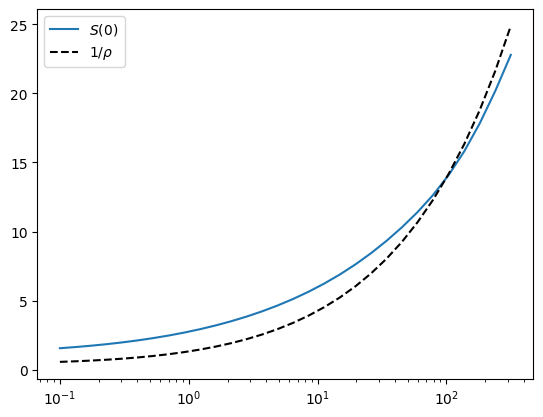

In [171]:
import numpy as np
import matplotlib.pyplot as plt

xi = np.asarray(xi, float)
xi_eq = np.asarray(xi_eq, float)

c = float(np.dot(xi_eq, xi) / np.dot(xi_eq, xi_eq))

plt.plot(taus, xi, label=r'$S(0)$ ')
plt.plot(taus, c * xi_eq, '--k', label=rf'$1/\rho$')
plt.xscale('log')
plt.legend()
plt.show()


In [172]:
r = np.arange(-100,100)
n = 1
PP_1 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

  0%|          | 0/30 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 30/30 [03:18<00:00,  6.62s/it]


In [173]:
r = np.arange(-100,100)
n = 2
PP_2 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

100%|██████████| 30/30 [23:38<00:00, 47.28s/it] 


In [174]:
r = np.arange(-100,100)
n = 3
PP_3 = [[array([kibble_x.P_n_correlations(n,ri,s)-kibble_x.P_n(n,s)**2 for ri in (r)]) for s in  tqdm(states)]]

  0%|          | 0/30 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 30/30 [1:06:54<00:00, 133.81s/it]


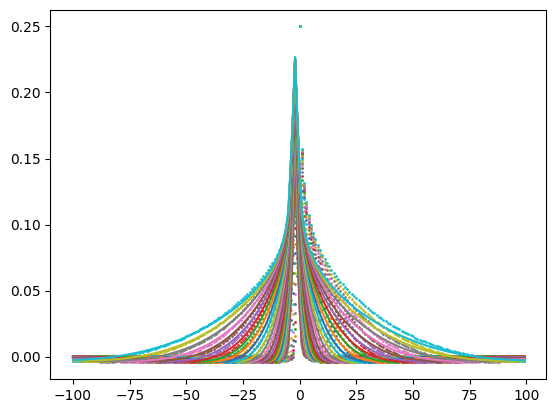

In [192]:
for p in PP_3[0]:
    plot(r,p)
for p in PP_1[0]:
    scatter(r,p,s=1)

In [199]:
FF_PP1= [FT([P]) for P in PP_1[0]]
peaks1 = []
for f in FF_PP1:
    peaks1+=[(f[0][k==0])]
FF_PP2= [FT([P]) for P in PP_2[0]]
peaks2 = []
for f in FF_PP2:
    peaks2+=[(f[0][k==0])]
FF_PP3= [FT([P]) for P in PP_3[0]]
peaks3 = []
for f in FF_PP3:
    peaks3+=[(f[0][k==0])]

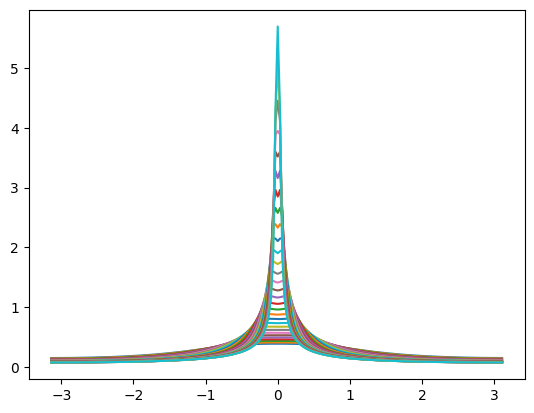

In [200]:
for f in FF_PP1:
    plot(k,abs(f[0]))

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


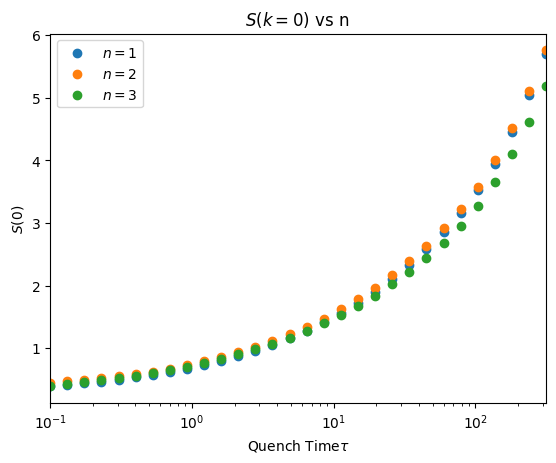

In [217]:
scatter(taus,peaks1,label=r"$n=1$")
scatter(taus,peaks2,label=r"$n=2$")
scatter(taus,peaks3,label=r"$n=3$")

xlabel(r"Quench Time$\tau$")
legend()
ylabel(r"$S(0)$")
xlim(taus[0],taus[-1])
title(r"$S(k=0)$ vs n ")
xscale("log")
#yscale("log")

In [352]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np

r = np.arange(-100, 100)
n_values = [1, 2, 3, 4]

def compute_Pn_corr(n, s):
    return np.array([
        kibble_x.P_n_correlations(n, ri, s) - kibble_x.P_n(n, s)**2
        for ri in r
    ])

def compute_for_n(n):
    # parallelize over all states for fixed n
    results = Parallel(n_jobs=-1)(
        delayed(compute_Pn_corr)(n, s) for s in tqdm(states, desc=f"n={n}")
    )
    return np.array(results)

# outer loop (n = 1..4)
PP_all = [compute_for_n(n) for n in n_values]
PP_all = np.array(PP_all)  # shape (4, len(states), len(r))


n=1:  32%|███▏      | 16/50 [00:00<00:00, 72.17it/s]/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschm

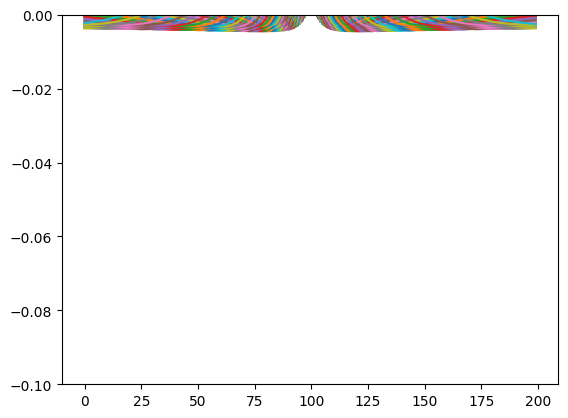

In [364]:
for i in np.arange(4):
    plot(PP_all[i,:,:].T)   
    ylim(-.1,0)

In [375]:
from equilibrium_critical_correlations import P_n_correlations, P_n
ns = array([1,2,3,4])


P_eq = [ array([P_n_correlations(n,ri)-P_n(n)**2 for ri in r]) for n in ns]

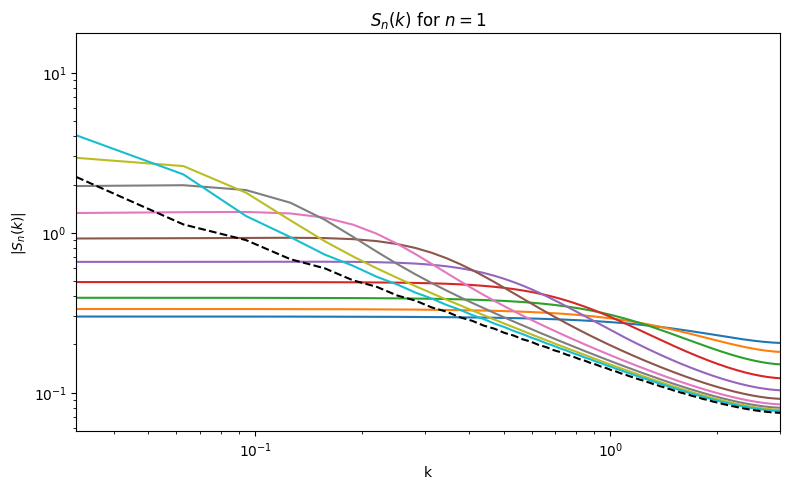

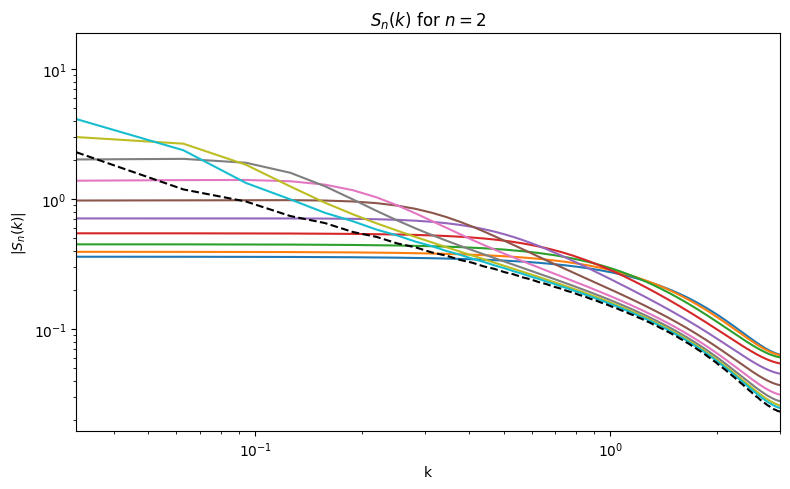

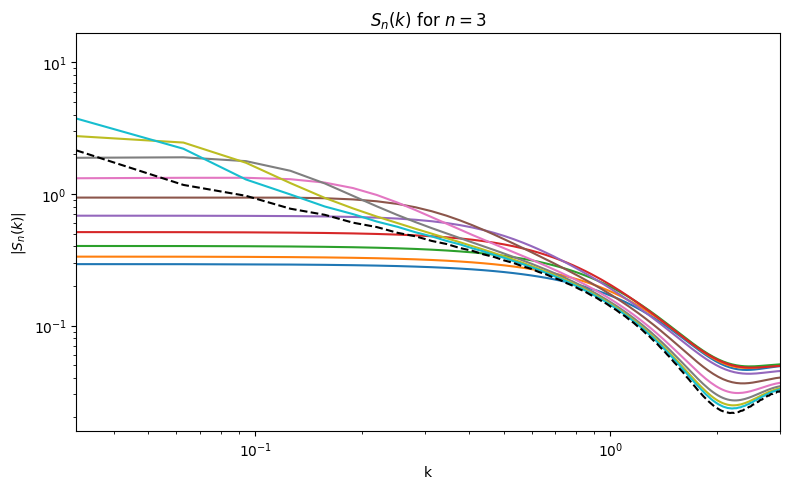

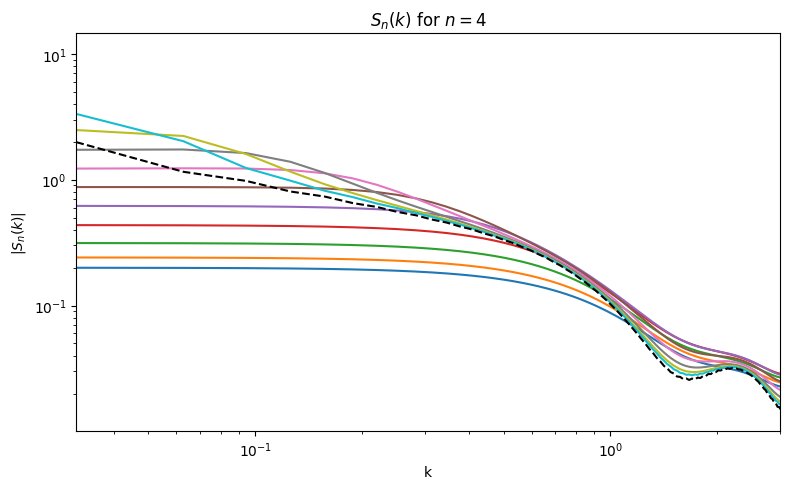

In [398]:
from numpy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import numpy as np

# user-adjustable parameters
start_idx = 1      # first state index
end_idx   = len(states)  # last state index (exclusive)
step_idx  = 5     # skip step, e.g. 5 → every 5th τ

N = len(r)
dr = r[1] - r[0]
k = fftshift(fftfreq(N, dr)) * 2 * np.pi   # wave numbers

for n_idx, n in enumerate([1, 2, 3, 4]):
    fig, ax = plt.subplots(figsize=(8, 5))
    data_n = PP_all[n_idx]     # shape: (len(states), len(r))

    for i in range(start_idx, end_idx, step_idx):
        tau = taus[i]
        F = np.abs(fftshift(fft(data_n[i])))
        F           # normalize
        ax.plot(k, F, label=rf"$\tau={tau}$")
    P_eq_f = FT(P_eq[n_idx])
    ax.plot(k,abs(P_eq_f),"--k")
    ax.set_title(rf"$S_n(k)$ for $n={n}$")
    ax.set_xlabel("k")
    ax.set_ylabel(r"$|S_n(k)|$")
    ax.set_xlim(k[1]-k[0], 3)
    ax.loglog()
    ax.set_yscale("log")
    #ax.plot(k,k**(-3/4)/4,":k")
    #ax.legend(fontsize=8)
    plt.tight_layout()
    
    filename =f"S_pp_n_{n}_loglog_legend.png"
   # plt.savefig(foldername+filename,dpi=800)
    plt.show()


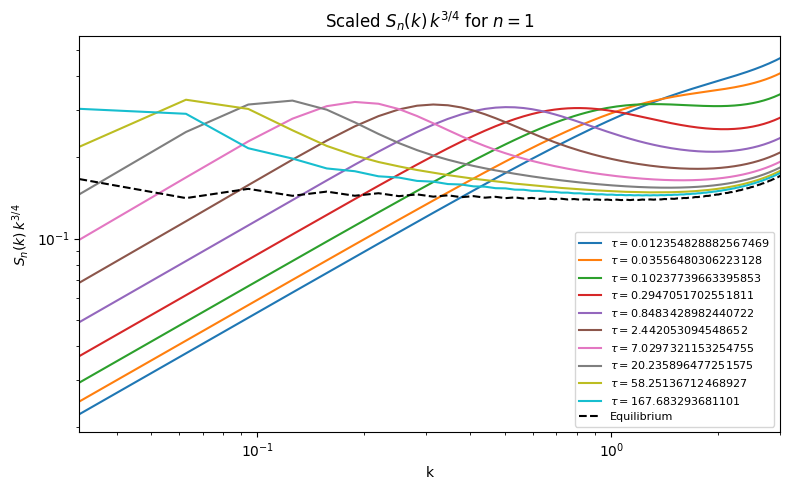

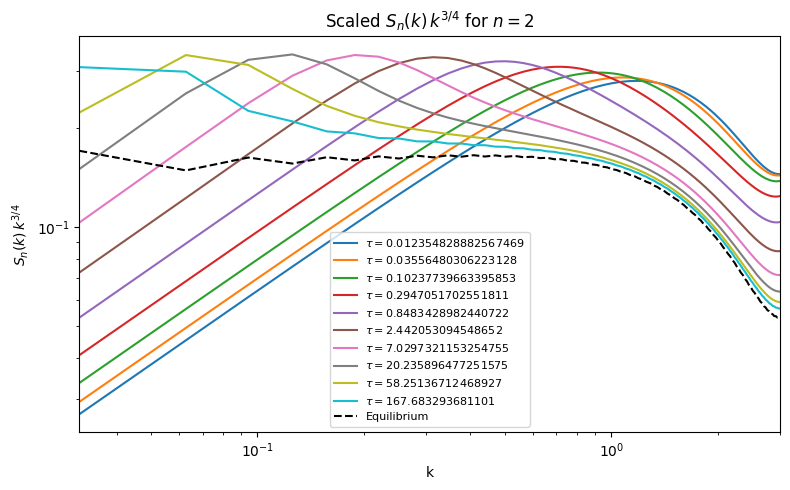

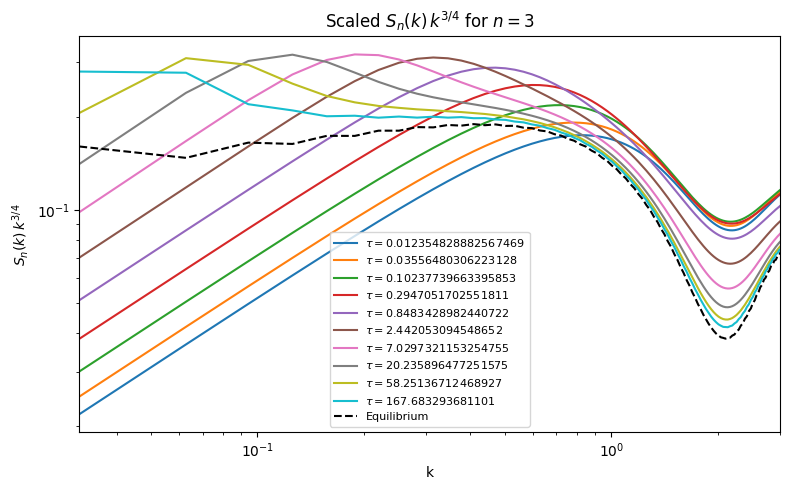

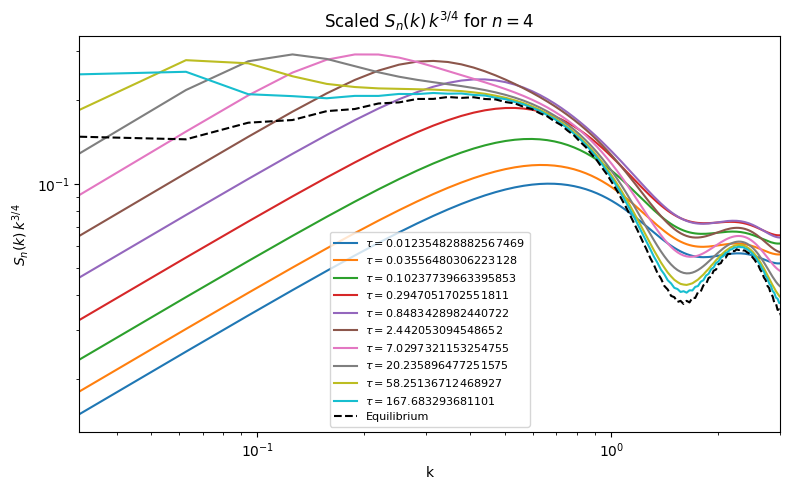

In [401]:
from numpy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import numpy as np

# adjustable sampling parameters
start_idx = 1
end_idx   = len(states)
step_idx  = 5

N = len(r)
dr = r[1] - r[0]
k = fftshift(fftfreq(N, dr)) * 2 * np.pi
k_abs = np.abs(k)
k_abs[k_abs == 0] = np.nan  # avoid zero singularity

for n_idx, n in enumerate([1, 2, 3, 4]):
    fig, ax = plt.subplots(figsize=(8, 5))
    data_n = PP_all[n_idx]  # shape: (len(states), len(r))

    for i in range(start_idx, end_idx, step_idx):
        tau = taus[i]
        F = np.abs(fftshift(fft(data_n[i])))
        stuff = F * (k_abs**(3/4))   # remove k^{-3/4} dependence
        ax.plot(k, stuff, label=rf"$\tau={tau}$")

    # equilibrium reference
    P_eq_f = FT(P_eq[n_idx])
    ax.plot(k, np.abs(P_eq_f) * (k_abs**(3/4)), "--k", label="Equilibrium")

    ax.set_title(rf"Scaled $S_n(k)\,k^{{3/4}}$ for $n={n}$")
    ax.set_xlabel("k")
    ax.set_ylabel(r"$S_n(k)\,k^{3/4}$")
    ax.set_xlim(k[1]-k[0], 3)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    plt.tight_layout()

    filename = f"S_pp_n_{n}_scaled.png"
    # plt.savefig(filename, dpi=800)
    plt.show()


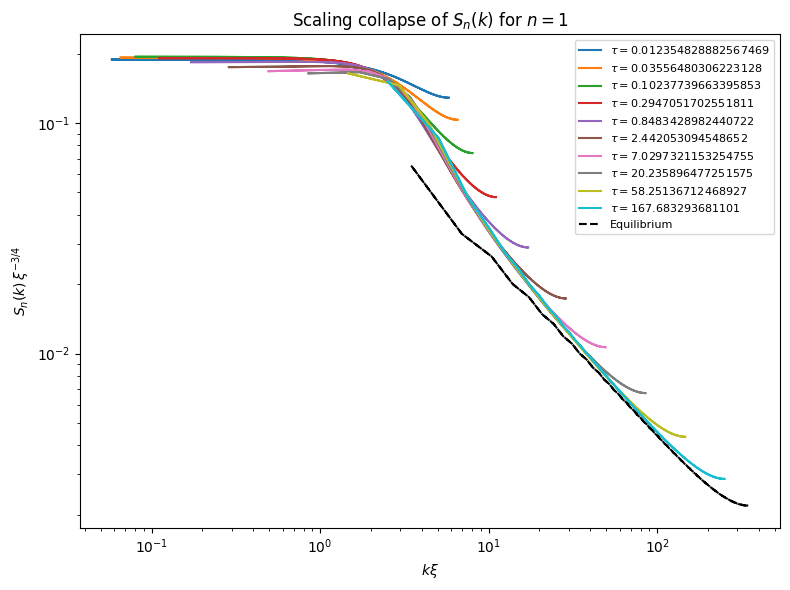

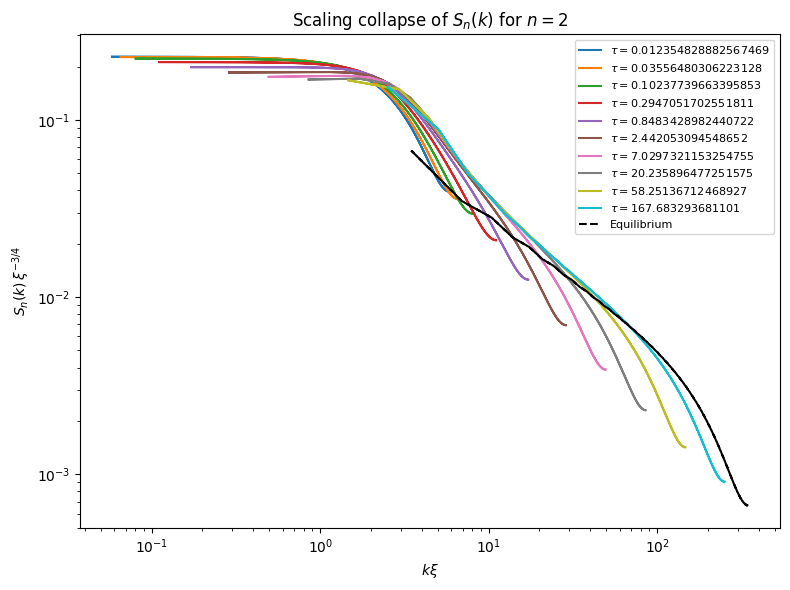

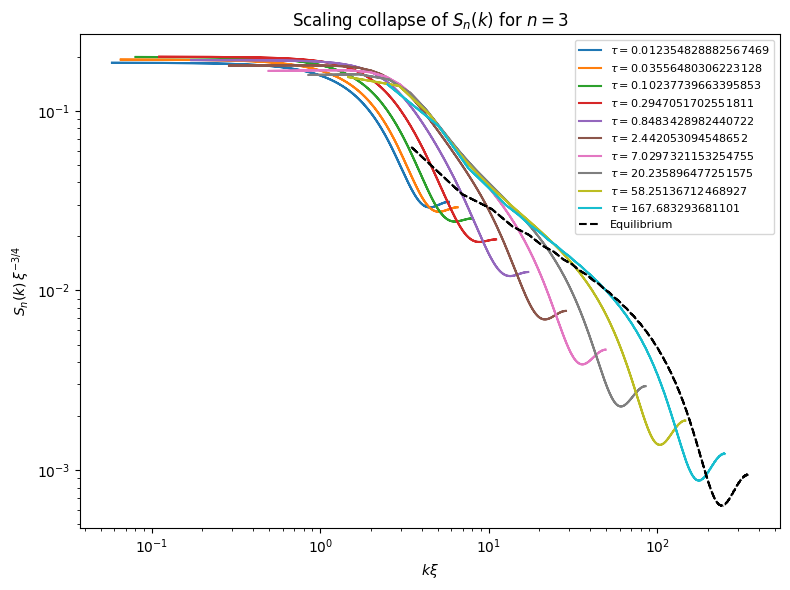

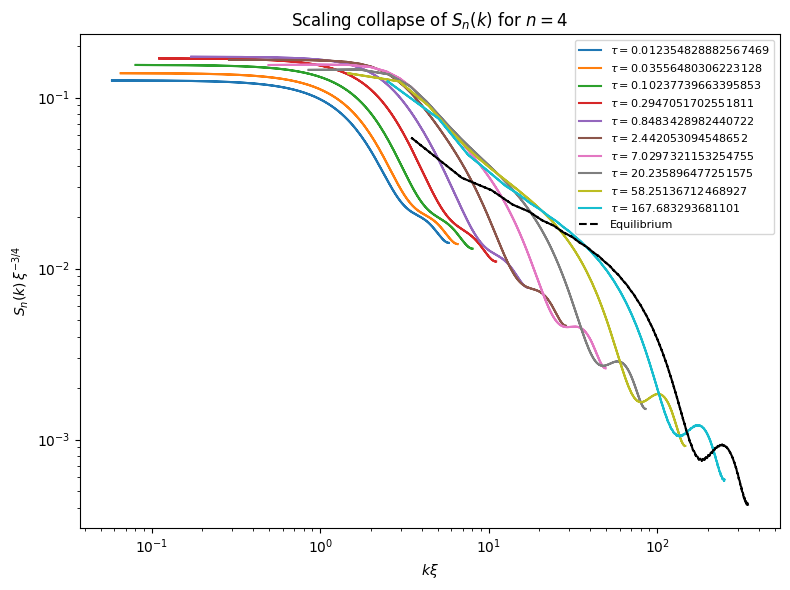

In [407]:
from numpy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import numpy as np

start_idx = 1
end_idx   = len(states)
step_idx  = 5

N = len(r)
dr = r[1] - r[0]
k = fftshift(fftfreq(N, dr)) * 2 * np.pi
k_abs = np.abs(k)
k_abs[k_abs == 0] = np.nan  # avoid division by zero

eta_x = 1/4

for n_idx, n in enumerate([1, 2, 3, 4]):
    fig, ax = plt.subplots(figsize=(8, 6))
    data_n = PP_all[n_idx]

    for i in range(start_idx, end_idx, step_idx):
        tau = taus[i]
        xi = xis[i]              # correlation length for this state
        F = np.abs(fftshift(fft(data_n[i])))

        scaled_k = k_abs * xi
        g = F * xi**(-3/4)       # remove prefactor to isolate g(kξ)
        ax.plot(scaled_k, g, label=rf"$\tau={tau}$")

    # optional: plot equilibrium reference
    P_eq_f = FT(P_eq[n_idx])
    eq_scaled_k = k_abs * xis[-1]
    g_eq = np.abs(P_eq_f) * xis[-1]**(-3/4)
    ax.plot(eq_scaled_k, g_eq, "--k", label="Equilibrium")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$k\xi$")
    ax.set_ylabel(r"$S_n(k)\,\xi^{-3/4}$")
    ax.set_title(rf"Scaling collapse of $S_n(k)$ for $n={n}$")
    ax.legend(fontsize=8)
    plt.tight_layout()

    #filename = f"S_pp_n_{n}_scalingcollapse.png"
    plt.savefig(filename, dpi=800)
    plt.show()


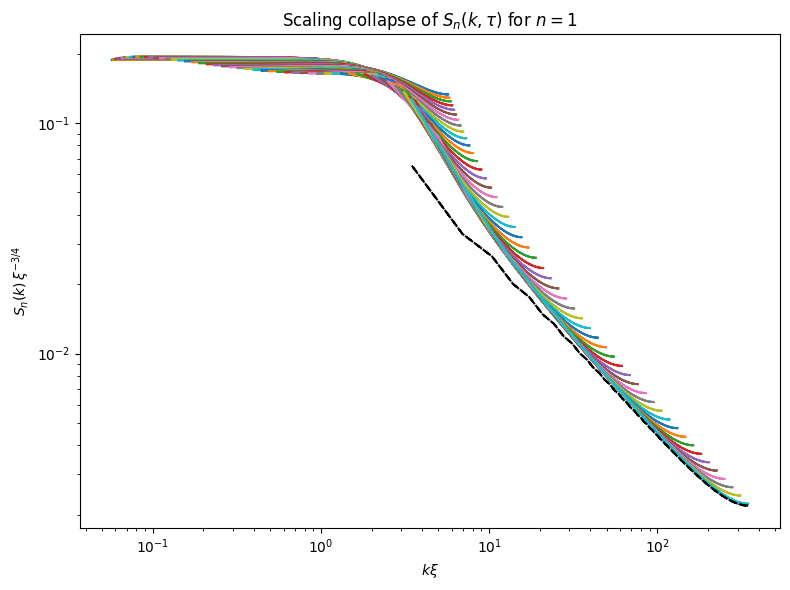

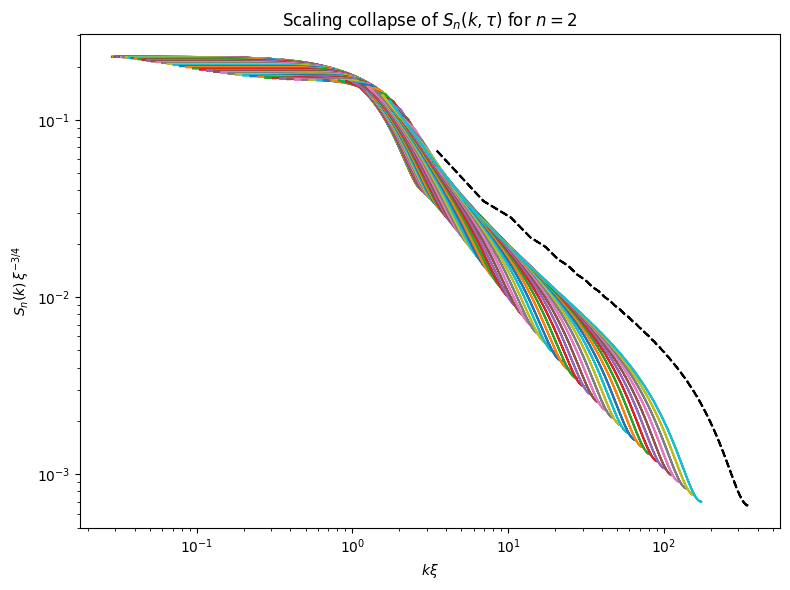

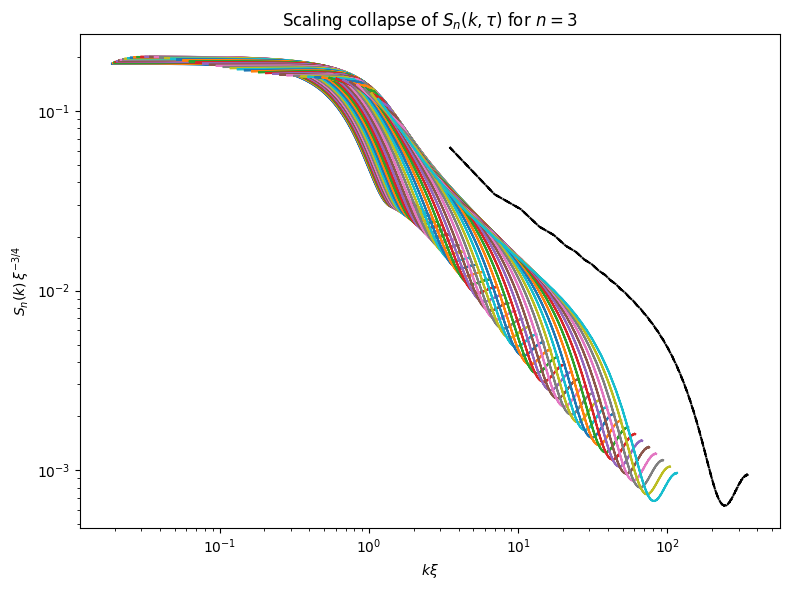

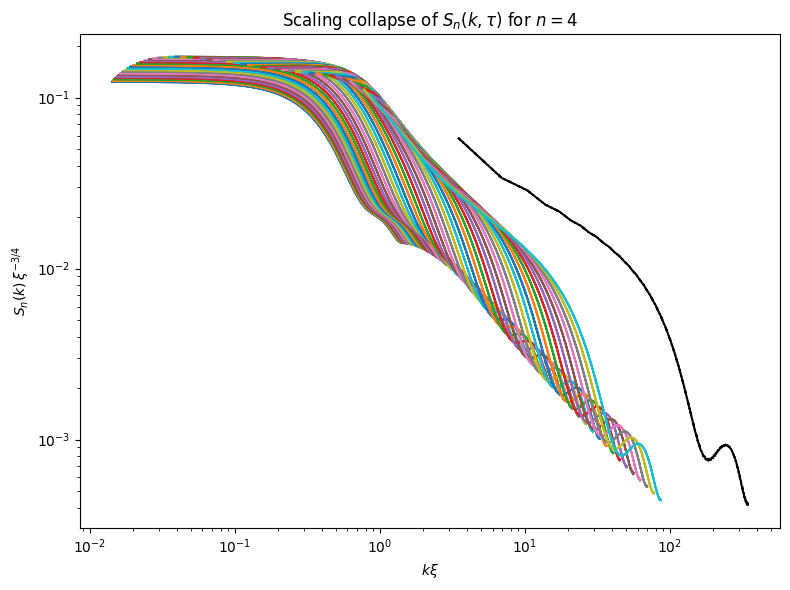

In [ ]:
from numpy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import numpy as np

eta_x = 1/4

N = len(r)
dr = r[1] - r[0]
k = fftshift(fftfreq(N, dr)) * 2 * np.pi
k_abs = np.abs(k)
k_abs[k_abs == 0] = np.nan  # avoid division by zero

for n_idx, n in enumerate([1, 2, 3, 4]):
    fig, ax = plt.subplots(figsize=(8,6))
    data_n = PP_all[n_idx]

    for i in range(0, len(taus), 1):   # use all or adjust step here
        tau = taus[i]
        xi = xis[i]
        F = np.abs(fftshift(fft(data_n[i])))

        scaled_k = k_abs * xi
        g = F * xi**(-3/4)            # scaling-collapse transformation
        ax.plot(scaled_k, g, label=rf"$\tau={tau}$")

    # add equilibrium reference curve
    P_eq_f = FT(P_eq[n_idx])
    scaled_k_eq = k_abs * xis[-1]
    g_eq = np.abs(P_eq_f) * xis[-1]**(-3/4)
    ax.plot(scaled_k_eq, g_eq, "--k", label="Equilibrium")

    # --- axes and styling ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$k \xi$")
    ax.set_ylabel(r"$S_n(k)\,\xi^{-3/4}$")
    ax.set_title(rf"Scaling collapse of $S_n(k,\tau)$ for $n={n}$")
    #ax.legend(fontsize=8)
    plt.tight_layout()

    # --- optional save ---
    filename = f"ScalingCollapse_Spp_n_{n}.png"
    # plt.savefig(filename, dpi=800)
    plt.show()


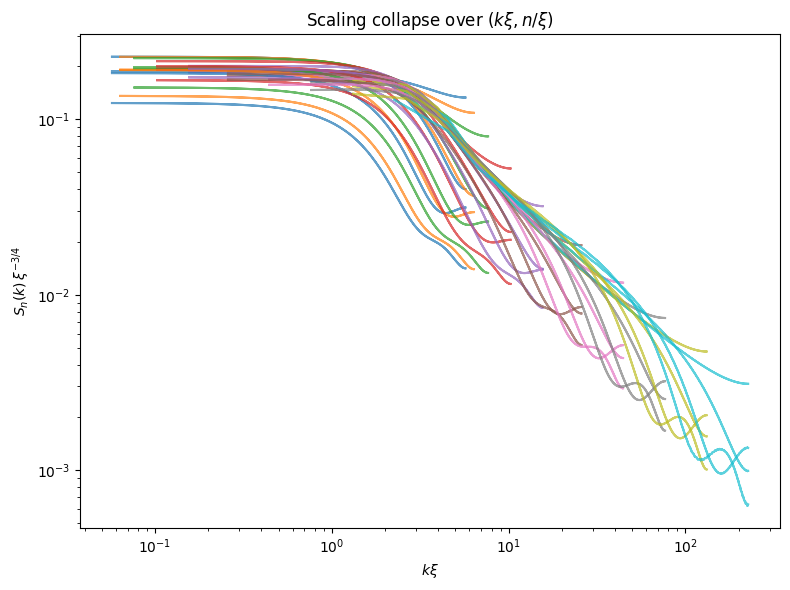

In [ ]:
from numpy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import numpy as np

eta_x = 1/4
N = len(r)
dr = r[1] - r[0]
k = fftshift(fftfreq(N, dr)) * 2 * np.pi
k_abs = np.abs(k)
k_abs[k_abs == 0] = np.nan

fig, ax = plt.subplots(figsize=(8,6))

for n_idx, n in enumerate([1, 2, 3, 4]):
    data_n = PP_all[n_idx]
    for i in range(0, len(taus), 5):
        xi = xis[i]
        F = np.abs(fftshift(fft(data_n[i])))
        scaled_k = k_abs * xi
        scaled_n = n / xi
        g = F * xi**(-3/4)
        ax.plot(scaled_k, g, label=rf"$n/\xi={scaled_n:.2f}$", alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$k\xi$")
ax.set_ylabel(r"$S_n(k)\,\xi^{-3/4}$")
ax.set_title(r"Scaling collapse over $(k\xi, n/\xi)$")
#ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_5553/1735985976.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


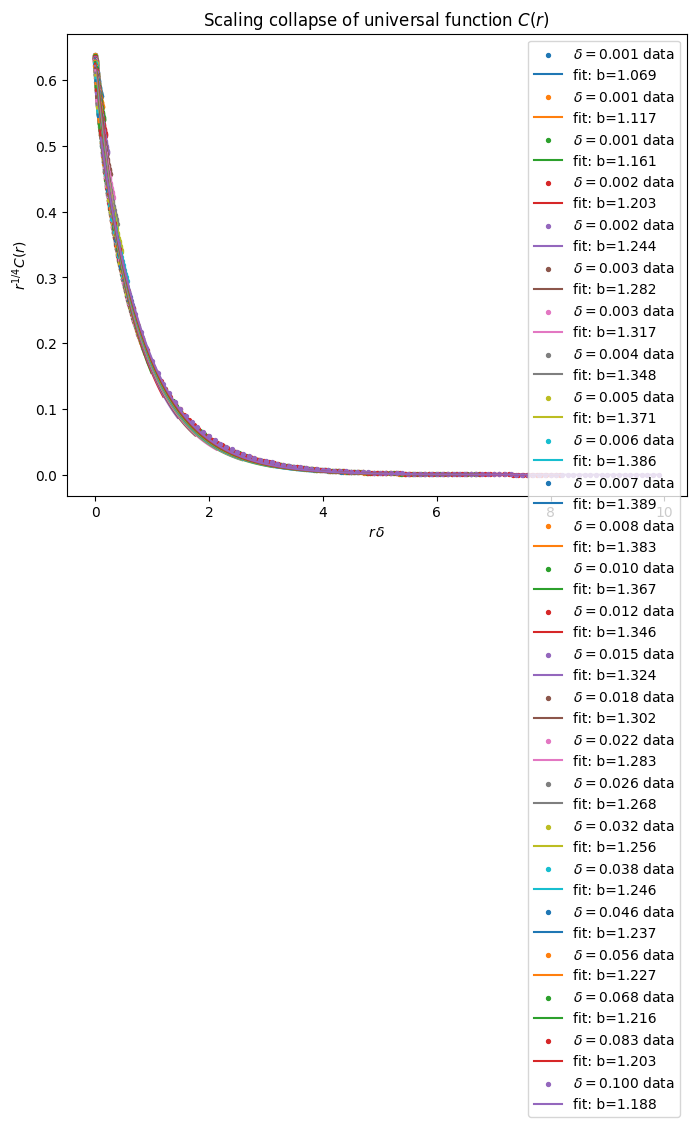

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit(x, a, b):
    return a * np.exp(-b * x)

plt.figure(figsize=(8,6))

for j in range(len(delta_values)):
    mask = r > 0
    xfit = r[mask] * abs(delta_values[j])
    yfit = X[j, mask] * r[mask]**(1/4)

    popt, _ = curve_fit(fit, xfit, yfit)
    a, b = popt

    plt.scatter(xfit, yfit, s=8, label=fr"$\delta={delta_values[j]:.3f}$ data")
    plt.plot(xfit, fit(xfit, a, b), '-', label=fr"fit: b={b:.3f}")

plt.xlabel(r"$r \, \delta$")
plt.ylabel(r"$r^{1/4} C(r)$")
plt.title("Scaling collapse of universal function $C(r)$")
plt.legend()
plt.tight_layout()
plt.show()


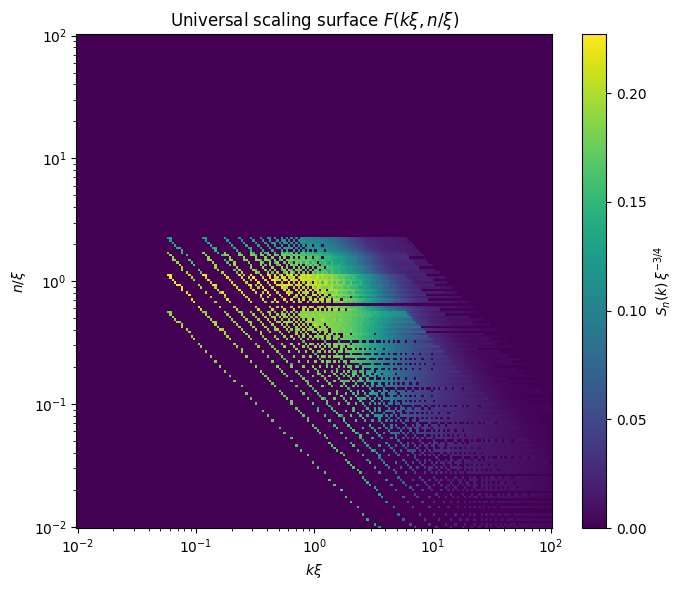

In [418]:
from numpy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import numpy as np

eta_x = 1/4
N = len(r)
dr = r[1] - r[0]
k = fftshift(fftfreq(N, dr)) * 2 * np.pi
k_abs = np.abs(k)
k_abs[k_abs == 0] = np.nan

# define scaling grids
x_values = np.logspace(-2, 2, 200)  # kξ
y_values = np.logspace(-2, 2, 200)  # n/ξ
F_grid = np.zeros((len(y_values), len(x_values)))

# accumulate samples into grid
counts = np.zeros_like(F_grid)

for n_idx, n in enumerate([1, 2, 3, 4]):
    data_n = PP_all[n_idx]
    for i in range(len(taus)):
        xi = xis[i]
        F = np.abs(fftshift(fft(data_n[i])))
        scaled_k = k_abs * xi
        scaled_n = n / xi
        g = F * xi**(-3/4)

        # bin each (kξ, n/ξ)
        for kk, val in zip(scaled_k, g):
            if np.isnan(kk): 
                continue
            x_idx = np.searchsorted(x_values, kk)
            y_idx = np.searchsorted(y_values, scaled_n)
            if 0 <= x_idx < len(x_values) and 0 <= y_idx < len(y_values):
                F_grid[y_idx, x_idx] += val
                counts[y_idx, x_idx] += 1

# normalize averages
counts[counts == 0] = 1
F_grid /= counts

# plot 2D scaling surface
fig, ax = plt.subplots(figsize=(7,6))
im = ax.pcolormesh(x_values, y_values, F_grid,
                   shading='auto', cmap='viridis')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$k\xi$")
ax.set_ylabel(r"$n/\xi$")
ax.set_title(r"Universal scaling surface $F(k\xi, n/\xi)$")
fig.colorbar(im, ax=ax, label=r"$S_n(k)\,\xi^{-3/4}$")
plt.tight_layout()
plt.show()
